**Decision Tree**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('../dataset/users.csv')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          99 non-null     int64
 1   Gender           99 non-null     str  
 2   Age              99 non-null     int64
 3   EstimatedSalary  99 non-null     int64
 4   Purchased        99 non-null     int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB


In [11]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,9.900000e+01,99.000000,99.000000,99.000000
mean,1.569127e+07,10.737374,57616.161616,0.191919
std,7.057936e+04,14.913072,33344.126268,0.395814
min,1.557077e+07,1.000000,15000.000000,0.000000
25%,1.563272e+07,1.000000,27000.000000,0.000000
50%,1.569483e+07,4.000000,52000.000000,0.000000
75%,1.574553e+07,10.500000,81500.000000,0.000000
max,1.581400e+07,64.000000,150000.000000,1.000000


In [12]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,12,19000,0
1,15810944,Male,11,20000,0
2,15668575,Female,1,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,10,76000,0


In [13]:
X = df.drop('Purchased',axis=1)
y = df['Purchased']

In [19]:
X = pd.get_dummies(X)
X

,User ID,Age,EstimatedSalary,Gender_Female,Gender_Male
0,15624510,12,19000,False,True
1,15810944,11,20000,False,True
2,15668575,1,43000,True,False
3,15603246,27,57000,True,False
4,15804002,10,76000,False,True
...,...,...,...,...,...
94,15786993,45,83000,True,False
95,15709441,35,44000,True,False
96,15710257,4,25000,True,False
97,15582492,5,123000,False,True


In [21]:
train_test_split(X)

[     User ID  Age  EstimatedSalary  Gender_Female  Gender_Male
 5   15728773    1            58000          False         True
 10  15570769    9            80000           True        False
 86  15694946   24            55000          False         True
 54  15654901    1            58000           True        False
 93  15699284    5            28000           True        False
 ..       ...  ...              ...            ...          ...
 63  15583681   32           120000          False         True
 36  15690188    4            28000           True        False
 96  15710257    4            25000           True        False
 15  15697686    2            80000          False         True
 18  15704583    4            28000          False         True
 
 [74 rows x 5 columns],
      User ID  Age  EstimatedSalary  Gender_Female  Gender_Male
 53  15671655    6            23000           True        False
 58  15642885    5            18000          False         True
 39  15782806 

In [22]:
DecisionTreeClassifier()

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   12            19000          0
1  15810944    Male   11            20000          0
2  15668575  Female    1            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   10            76000          0


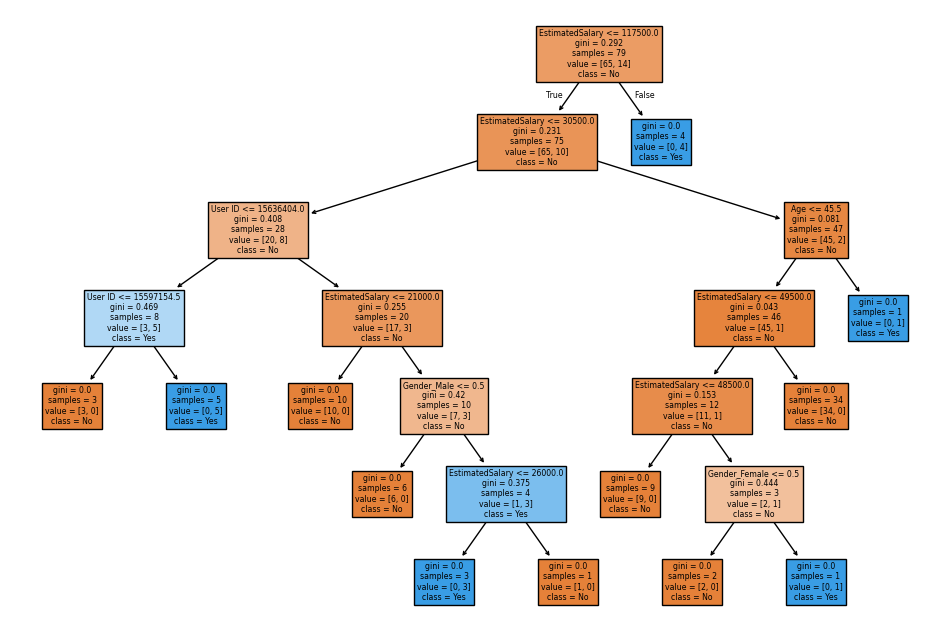

Training Accuracy: 1.0
Testing Accuracy: 0.75


In [25]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../dataset/users.csv")

# Display dataset
print(df.head())

# Assign predictors and target
X = df.drop('Purchased', axis=1)   # predictors
y = df['Purchased']                # target

# Apply encoding using get_dummies()
X = pd.get_dummies(X)

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Draw Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Evaluate performance
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)